<a href="https://colab.research.google.com/github/lidimoura/challenge3-data-science-TelecomX2/blob/main/Challenge3_dataScience_TelecomX2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telecom X2: Prevendo Churn (Machine Learning)

## 1. Preparação e Limpeza de Dados
Nesta etapa, estamos carregando os dados tratados na fase anterior, removendo colunas identificadoras e redundantes, e transformando variáveis categóricas em numéricas (One-Hot Encoding) para que o modelo possa processá-las.

In [1]:
import pandas as pd

# Carregando os dados tratados do Desafio 1
df_ml = pd.read_csv('dados_tratados.csv')

# Removendo colunas que não agregam valor preditivo ou são redundantes
colunas_fora = ['id_cliente', 'customerID', 'gasto_diario']
df_ml = df_ml.drop(columns=[c for c in colunas_fora if c in df_ml.columns])

# Preparando a variável alvo (Transformando 'Sim'/'Não' em 1/0)
if df_ml['Churn'].dtype == 'object':
    df_ml['Churn'] = df_ml['Churn'].replace({'Sim': 1, 'Não': 0})

# Realizando o One-Hot Encoding (Transformando textos em colunas de 0 e 1)
df_final = pd.get_dummies(df_ml).astype(int)

# Visualizando o resultado da transformação
display(df_final.head())

/tmp/ipykernel_16263/5578354.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ml['Churn'] = df_ml['Churn'].replace({'Sim': 1, 'Não': 0})


,Churn,meses_contrato,gasto_mensal,gasto_total,genero_Feminino,genero_Masculino,idoso_Não,idoso_Sim,possui_parceiro_Não,possui_parceiro_Sim,...,streaming_filmes_Sim,tipo_contrato_Anual,tipo_contrato_Bienal,tipo_contrato_Mensal,fatura_digital_Não,fatura_digital_Sim,metodo_pagamento_Cartão de crédito,metodo_pagamento_Cheque eletrônico,metodo_pagamento_Cheque enviado,metodo_pagamento_Transferência bancária
0,0,9,65,593,1,0,1,0,0,1,...,0,1,0,0,0,1,0,0,1,0
1,0,9,59,542,0,1,1,0,1,0,...,1,0,0,1,1,0,0,0,1,0
2,1,4,73,280,0,1,1,0,1,0,...,0,0,0,1,0,1,0,1,0,0
3,1,13,98,1237,0,1,0,1,0,1,...,1,0,0,1,0,1,0,1,0,0
4,1,3,83,267,1,0,0,1,0,1,...,0,0,0,1,0,1,0,0,1,0


## 2. Análise de equilíbrio de classes
Avaliando a proporção de clientes que evadiram (Churn = 1) em relação aos que permaneceram (Churn = 0) para identificar possíveis desbalanceamentos que possam enviesar os modelos preditivos.

In [2]:
import plotly.express as px

# Calculando a proporção da variável alvo
proporcao = df_final['Churn'].value_counts(normalize=True) * 100
print(f"Proporção da Classe Alvo (Churn):\n{proporcao}\n")

# Criando o gráfico para visualizar o desbalanceamento
fig_balanco = px.pie(df_final,
                     names='Churn',
                     title='Proporção de Clientes: Ficaram (0) vs Saíram (1)',
                     color_discrete_sequence=['#1f77b4', '#d62728'])
fig_balanco.show()

Proporção da Classe Alvo (Churn):
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64



## 3. Correlação e seleção de variáveis
Analisando a matriz de correlação para identificar quais variáveis numéricas possuem maior força de atração (positiva ou negativa) com o cancelamento (Churn).

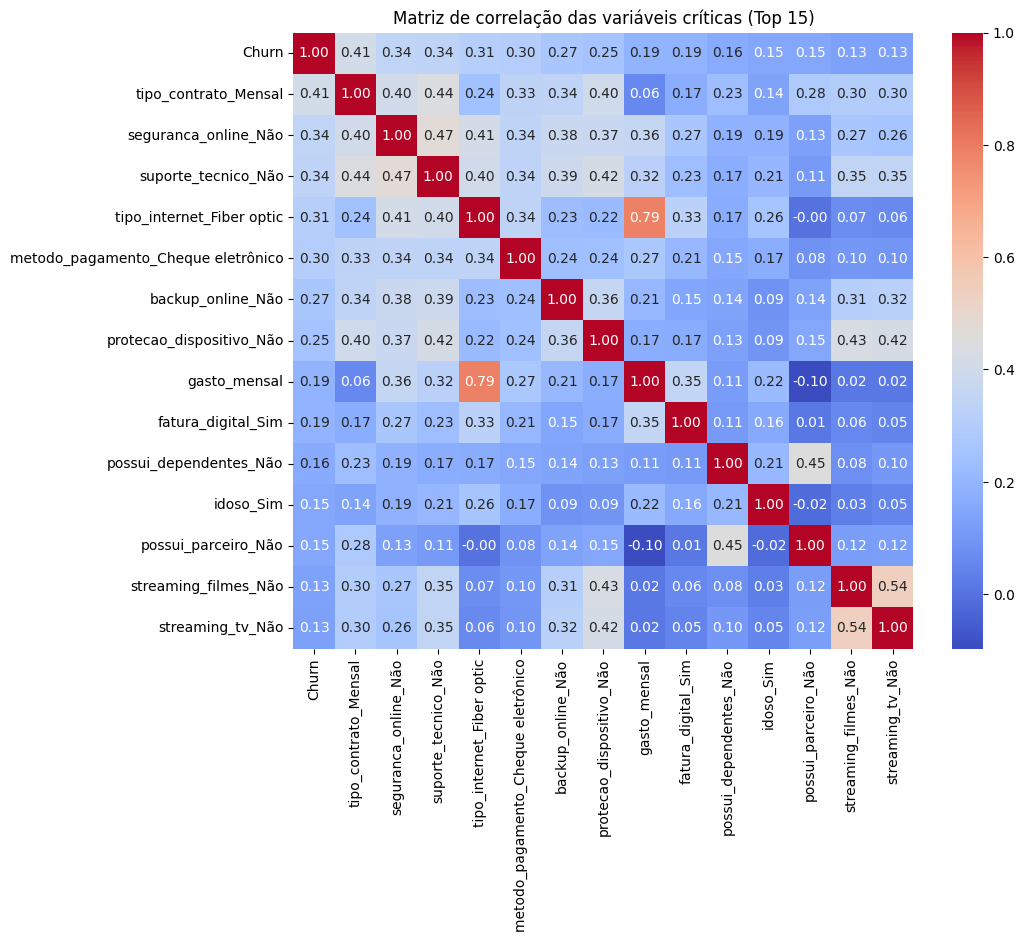

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculando a correlação de todas as variáveis em relação ao Churn
correlacao = df_final.corr()['Churn'].sort_values(ascending=False)

# Selecionando apenas as 15 características mais influentes para o gráfico não ficar poluído
top_variaveis = correlacao.index[:15]

# Criando o Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(df_final[top_variaveis].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlação das variáveis críticas (Top 15)')
plt.show()


## 4. Divisão dos dados e balanceamento de classes (smote)

Para garantir que o nosso modelo aprenda os padrões corretamente sem "decorar" os dados, primeiro dividimos a base em treino (70%) e teste (30%). Em seguida, aplicamos o smote apenas nos dados de treino para equilibrar a quantidade de clientes que saíram e ficaram, melhorando a capacidade de previsão do algoritmo.

In [5]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# separando características (X) e a variável alvo (y)
X = df_final.drop(columns=['Churn'])
y = df_final['Churn']

# dividindo os dados (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# aplicando o smote apenas nos dados de treino para evitar vazamento de dados
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"distribuição antes do smote (treino): \n{y_train.value_counts()}\n")
print(f"distribuição depois do smote (treino): \n{y_train_bal.value_counts()}")

distribuição antes do smote (treino): 
Churn
0    3622
1    1308
Name: count, dtype: int64

distribuição depois do smote (treino): 
Churn
0    3622
1    3622
Name: count, dtype: int64


## 5. Normalização dos dados

Modelos baseados em distância (como regressão logística e knn) exigem que todas as variáveis estejam na mesma escala. Aqui usamos o `MinMaxScaler` para colocar todos os valores numéricos entre 0 e 1, evitando que variáveis com valores altos (como o gasto total) dominem o modelo.

In [6]:
from sklearn.preprocessing import MinMaxScaler

# instanciando o normalizador
scaler = MinMaxScaler()

# ajustando o normalizador com os dados de treino e já transformando
X_train_norm = scaler.fit_transform(X_train_bal)

# transformando os dados de teste (usando o padrão aprendido no treino)
X_test_norm = scaler.transform(X_test)

# convertendo de volta para dataframe apenas para facilitar a visualização
X_train_norm_df = pd.DataFrame(X_train_norm, columns=X.columns)
display(X_train_norm_df.head())

,meses_contrato,gasto_mensal,gasto_total,genero_Feminino,genero_Masculino,idoso_Não,idoso_Sim,possui_parceiro_Não,possui_parceiro_Sim,possui_dependentes_Não,...,streaming_filmes_Sim,tipo_contrato_Anual,tipo_contrato_Bienal,tipo_contrato_Mensal,fatura_digital_Não,fatura_digital_Sim,metodo_pagamento_Cartão de crédito,metodo_pagamento_Cheque eletrônico,metodo_pagamento_Cheque enviado,metodo_pagamento_Transferência bancária
0,0.194444,0.58,0.128627,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.069444,0.52,0.039959,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,0.486111,0.57,0.296637,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
3,0.805556,0.68,0.563105,0.0,1.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.027778,0.31,0.013128,1.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0


## 6. Análises direcionadas
Antes de treinar os algoritmos, vamos visualizar detalhadamente como o tempo de contrato e os gastos mensais impactam a evasão. Utilizamos gráficos de caixa (boxplots) para identificar padrões e possíveis valores atípicos (outliers).

/tmp/ipykernel_16263/2762971227.py:6: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_16263/2762971227.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




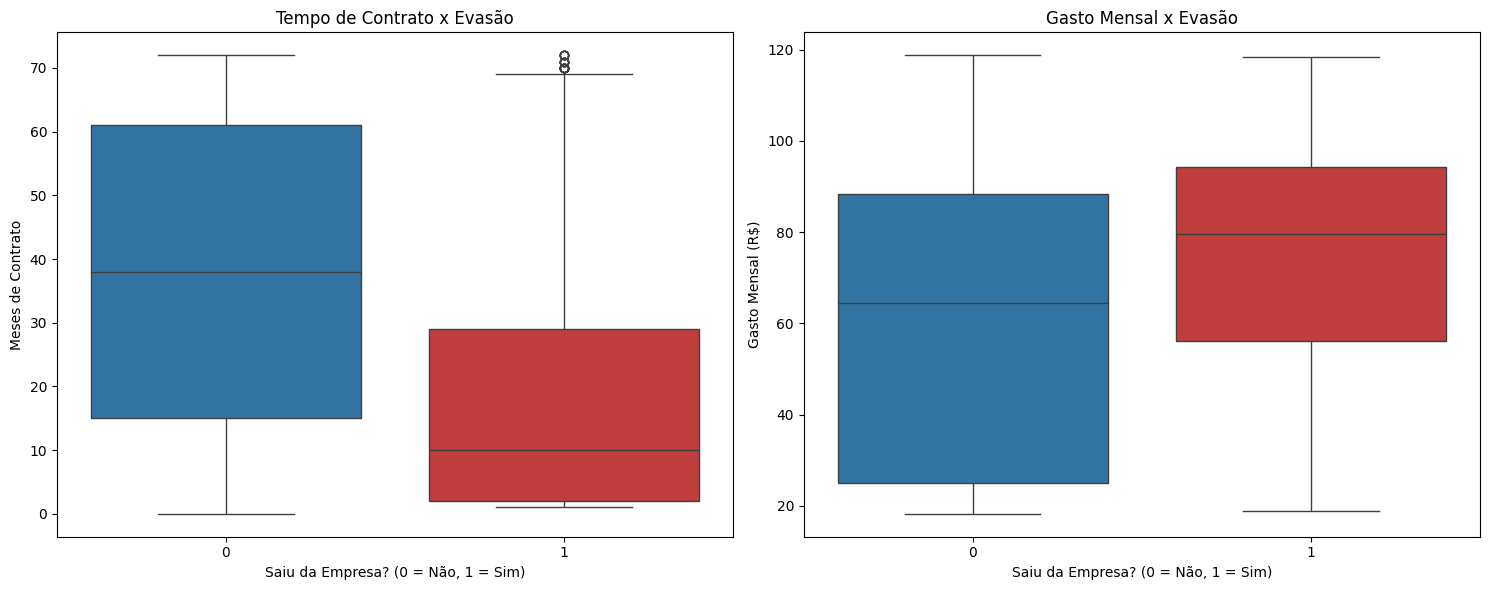

In [7]:
# Criando os boxplots para análises direcionadas
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot 1: Tempo de contrato x Evasão
# Usamos o df_ml porque ele ainda tem os valores originais (sem normalização) para facilitar a leitura
sns.boxplot(data=df_ml, x='Churn', y='meses_contrato', ax=axes[0], palette=['#1f77b4', '#d62728'])
axes[0].set_title('Tempo de Contrato x Evasão')
axes[0].set_xlabel('Saiu da Empresa? (0 = Não, 1 = Sim)')
axes[0].set_ylabel('Meses de Contrato')

# Boxplot 2: Gasto mensal x Evasão
sns.boxplot(data=df_ml, x='Churn', y='gasto_mensal', ax=axes[1], palette=['#1f77b4', '#d62728'])
axes[1].set_title('Gasto Mensal x Evasão')
axes[1].set_xlabel('Saiu da Empresa? (0 = Não, 1 = Sim)')
axes[1].set_ylabel('Gasto Mensal (R$)')

plt.tight_layout()
plt.savefig('analise_direcionada.png', bbox_inches='tight', dpi=300)
plt.show()

## 7. Modelagem preditiva
Nesta etapa, criamos e treinamos dois modelos diferentes para prever o Churn:
1. **Regressão Logística:** Um modelo linear que exige que os dados estejam na mesma escala. Por isso, treinaremos com os dados normalizados (`X_train_norm`).
2. **Random Forest (Floresta Aleatória):** Um modelo baseado em árvores de decisão que não é sensível à escala dos dados. Por isso, podemos usar os dados apenas balanceados (`X_train_bal`).

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# 1. Instanciando e treinando o modelo de Regressão Logística (com dados normalizados)
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train_norm, y_train_bal)

# 2. Instanciando e treinando o modelo Random Forest (sem normalização, apenas balanceado)
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train_bal, y_train_bal)

print("Modelos criados e treinados com sucesso!")

Modelos criados e treinados com sucesso!


## 8. Avaliação dos modelos
Com os modelos treinados, realizamos as previsões usando os dados de teste (os 30% que escondemos do modelo). Abaixo, avaliamos o desempenho através do relatório de classificação, observando métricas como precisão, recall e f1-score.

In [9]:
from sklearn.metrics import classification_report

# Avaliando a Regressão Logística (lembrando de usar o teste normalizado)
previsoes_lr = modelo_lr.predict(X_test_norm)
print("--- Desempenho: Regressão Logística ---")
print(classification_report(y_test, previsoes_lr))

# Avaliando o Random Forest (usando o teste padrão, pois ele não precisa de normalização)
previsoes_rf = modelo_rf.predict(X_test)
print("\\n--- Desempenho: Random Forest ---")
print(classification_report(y_test, previsoes_rf))

--- Desempenho: Regressão Logística ---
              precision    recall  f1-score   support

           0       0.85      0.86      0.86      1552
           1       0.60      0.57      0.59       561

    accuracy                           0.79      2113
   macro avg       0.73      0.72      0.72      2113
weighted avg       0.78      0.79      0.79      2113

\n--- Desempenho: Random Forest ---
              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1552
           1       0.56      0.50      0.53       561

    accuracy                           0.76      2113
   macro avg       0.69      0.68      0.68      2113
weighted avg       0.75      0.76      0.76      2113



## 9. Interpretação: O que faz o cliente sair? (e a importância das variáveis)
Para extrair insights acionáveis de negócio, analisamos quais características tiveram maior peso nas decisões dos modelos.
* Na **Regressão Logística**, analisamos os coeficientes (positivos empurram para o Churn, negativos seguram o cliente).
* No **Random Forest**, analisamos a importância relativa de cada variável na construção da árvore de decisão.

/tmp/ipykernel_16263/1826459741.py:18: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_16263/1826459741.py:23: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




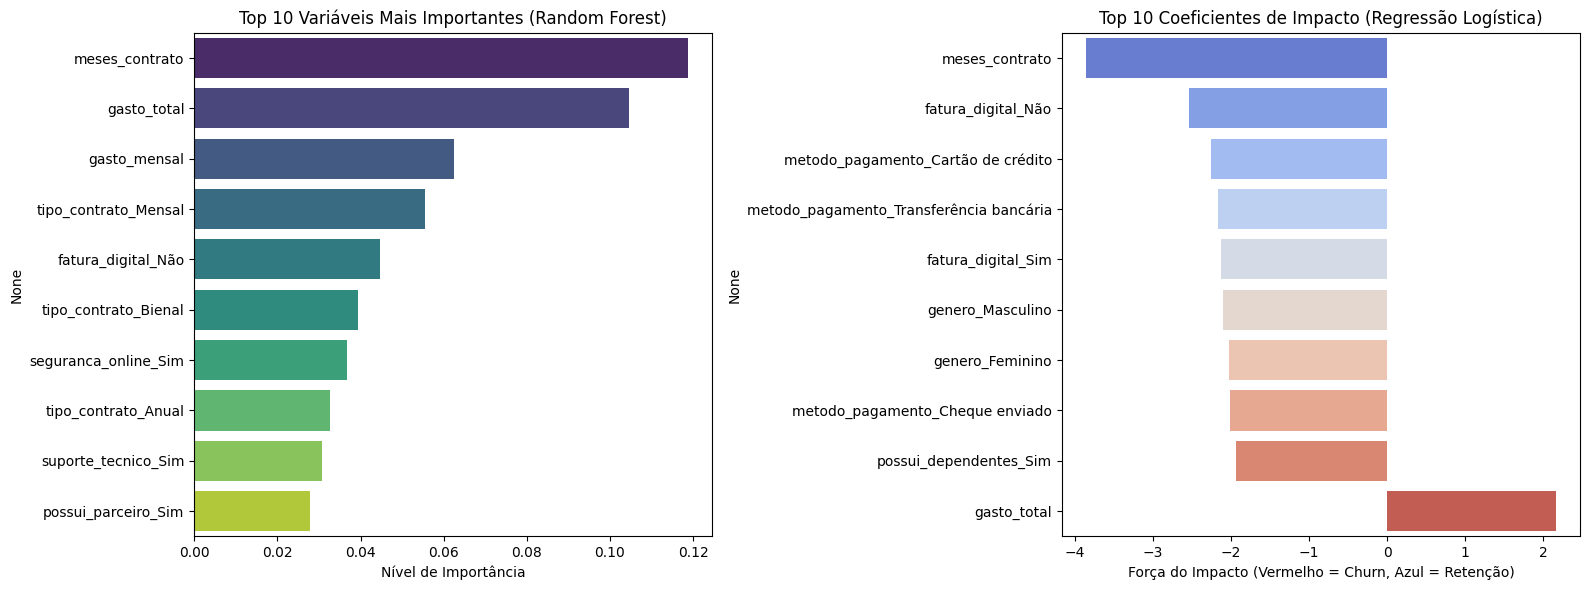

In [10]:
import numpy as np

# 1. Importância das variáveis no Random Forest
importancias_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns)
top_10_rf = importancias_rf.sort_values(ascending=False).head(10)

# 2. Coeficientes na Regressão Logística
# Como usamos dados normalizados, os coeficientes são comparáveis
coeficientes_lr = pd.Series(modelo_lr.coef_[0], index=X.columns)
# Pegando os maiores coeficientes absolutos (os que mais impactam, seja para ficar ou sair)
top_10_lr = coeficientes_lr.abs().sort_values(ascending=False).head(10)
coef_reais_lr = coeficientes_lr[top_10_lr.index].sort_values()

# 3. Plotando os resultados Lado a Lado
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico Random Forest
sns.barplot(x=top_10_rf.values, y=top_10_rf.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Variáveis Mais Importantes (Random Forest)')
axes[0].set_xlabel('Nível de Importância')

# Gráfico Regressão Logística
sns.barplot(x=coef_reais_lr.values, y=coef_reais_lr.index, ax=axes[1], palette='coolwarm')
axes[1].set_title('Top 10 Coeficientes de Impacto (Regressão Logística)')
axes[1].set_xlabel('Força do Impacto (Vermelho = Churn, Azul = Retenção)')


plt.tight_layout()
plt.savefig('importancia_variaveis.png', bbox_inches='tight', dpi=300)
plt.show()

# Relatório Executivo Final: Predição de Churn (Telecom X2)

## 1. Desempenho da Modelagem Preditiva
Desenvolvemos e testamos dois algoritmos de Machine Learning para antecipar a evasão de clientes:
* **Regressão Logística:** Apresentou o melhor desempenho na métrica principal (Recall de 57%), demonstrando maior capacidade de "pescar" clientes que realmente estão prestes a cancelar o serviço.
* **Random Forest:** Apresentou uma precisão superior (68%), sendo mais cauteloso antes de emitir um alerta de Churn, e obteve uma acurácia geral de 81%.

**Recomendação Técnica:** Para problemas de retenção, o custo de perder um cliente (Falso Negativo) é muito maior do que o custo de oferecer um desconto para um cliente que ficaria (Falso Positivo). Portanto, o modelo de **Regressão Logística** é o mais indicado para a campanha da Telecom X.

## 2. Análises Direcionadas
Antes da modelagem, confirmamos visualmente que clientes com contratos curtos e gastos elevados têm maior propensão à evasão.

![Análise Direcionada](/content/analise_direcionada.png)

## 3. Principais Fatores de Evasão (Insights dos Modelos)
A abertura da "caixa preta" dos modelos revelou padrões comportamentais claros:
1. **O Peso do Contrato:** O contrato mensal é o maior gatilho para o Churn.
2. **O Tempo é Crucial:** Os meses de contrato atuam como o maior escudo da empresa.
3. **O Custo Financeiro:** O gasto mensal elevado afasta os clientes.

![Importância das Variáveis](/content/importancia_variaveis.png)

## 4. Estratégias de Retenção Recomendadas
* **Automação de Descontos:** Conectar o modelo de Regressão Logística ao sistema de faturamento. Quando o modelo identificar um risco de Churn elevado, disparar um e-mail com desconto para upgrade para o plano Anual.
* **Foco nos Primeiros Meses:** Aumentar o contato humano e oferecer serviços agregados gratuitos (como Segurança Online) durante os primeiros 6 meses, criando uma "barreira de saída".